# Demo 8 (PE): Analyzing Keypoint Displacement and Action Units in human facial pose data from OpenFace

*Written and last updated September 18, 2025 by Sedona Ewbank, snewbank@stanford.edu*

The purpose of this demo is to demonstrate how to measure and plot keypoint travel and action unit usage from OpenFace data. The citation for OpenFace is given below - note that this notebook includes some instructions for how to acquire MARIPoSA-compatible facial pose data using OpenFace:

    T. Baltrušaitis, P. Robinson and L. -P. Morency, "OpenFace: An open source facial behavior analysis toolkit," 2016 IEEE Winter Conference on Applications of Computer Vision (WACV), Lake Placid, NY, USA, 2016, pp. 1-10, doi: 10.1109/WACV.2016.7477553.

The source video data for this demo notebook, analyzed in OpenFace, is a subset of the CelebV-HQ dataset (reference below). Accordingly, the config file with online video identifiers and their emotion annoations, as provided in the CelebV-HQ dataset, is not reproduced in the demo source data but may be acquired by following the authors' instructions.

    Zhu, H., et al.: CelebV-HQ: a large-scale video facial attributes dataset. In: Avidan, S., Brostow, G., Cissé, M., Farinella, G.M., Hassner, T. (eds.) ECCV 2022. LNCS, vol. 13667, pp. 650–667. Springer, Cham (2022). https://doi.org/10.1007/978-3-031-20071-7_38

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from scipy.stats import ttest_ind
from sklearn.decomposition import PCA
from utils import analyze, plot, metadata, simulate
import json
import importlib
from matplotlib.animation import FuncAnimation, FFMpegWriter
from IPython.display import HTML

importlib.reload(metadata)
importlib.reload(analyze)
importlib.reload(plot)
importlib.reload(simulate)

<module 'utils.simulate' from '/Users/snewbank/PycharmProjects/MARIPoSA/utils/simulate.py'>

## 8.0: Getting familiar with OpenFace data

Before starting keypoint or action unit analysis, it is worthwhile to get acquainted with the indexing of keypoints and action units in data output by OpenFace. For analysis with MARIPoSA, it is probably best to analyze videos in OpenFace with the FeatureExtraction command using flags "-2Dfp -pose -aus -gaze -tracked -f". 

Below, once the config for the demo project is loaded, the keypoints in an individual video frame tracked by OpenFace are plotted with indices overlaid to see what keypoint information is gained. 

In [16]:
config = metadata.load_project('/Volumes/snewbank_drive/CelebV-HQ-main//250911_CelebOF-mariposa/config_PE.yaml')

chin
[['x_0', 'y_0'], ['x_1', 'y_1'], ['x_2', 'y_2'], ['x_3', 'y_3'], ['x_4', 'y_4'], ['x_5', 'y_5'], ['x_6', 'y_6'], ['x_7', 'y_7'], ['x_8', 'y_8'], ['x_9', 'y_9'], ['x_10', 'y_10'], ['x_11', 'y_11'], ['x_12', 'y_12'], ['x_13', 'y_13'], ['x_14', 'y_14'], ['x_15', 'y_15'], ['x_16', 'y_16']]
eyebrows
[['x_17', 'y_17'], ['x_18', 'y_18'], ['x_19', 'y_19'], ['x_20', 'y_20'], ['x_21', 'y_21'], ['x_22', 'y_22'], ['x_23', 'y_23'], ['x_24', 'y_24'], ['x_25', 'y_25'], ['x_26', 'y_26']]
eyes
[['x_36', 'y_36'], ['x_37', 'y_37'], ['x_38', 'y_38'], ['x_39', 'y_39'], ['x_40', 'y_40'], ['x_41', 'y_41'], ['x_42', 'y_42'], ['x_43', 'y_43'], ['x_44', 'y_44'], ['x_45', 'y_45'], ['x_46', 'y_46'], ['x_47', 'y_47']]
nose
[['x_27', 'y_27'], ['x_28', 'y_28'], ['x_29', 'y_29'], ['x_30', 'y_30'], ['x_31', 'y_31'], ['x_32', 'y_32'], ['x_33', 'y_33'], ['x_34', 'y_34'], ['x_35', 'y_35']]
mouth
[['x_48', 'y_48'], ['x_49', 'y_49'], ['x_50', 'y_50'], ['x_51', 'y_51'], ['x_52', 'y_52'], ['x_53', 'y_53'], ['x_54', 'y_5

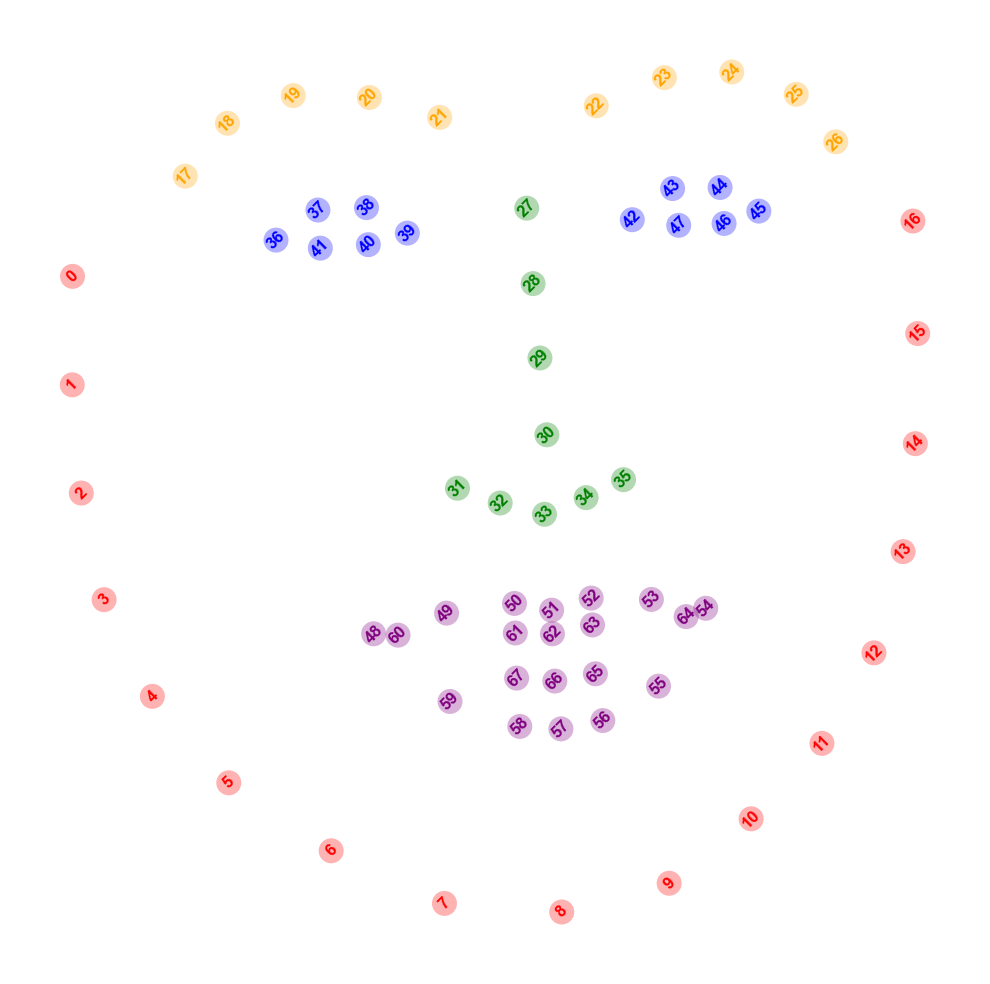

In [17]:
test_df = pd.read_csv(config["data_directory"]+"/"+config["project_files"][1])
test_df.columns = test_df.columns.str.replace(' ', '')
x_coords = [i for i in test_df.columns if i.lower().startswith("x_")]
y_coords = [i for i in test_df.columns if i.lower().startswith("y_")]
keypoints = ["kp"+i.split("y")[1] for i in y_coords]
kp_dict = {}
kp_dict["chin"]=[]
kp_dict["eyebrows"]=[]
kp_dict["eyes"]=[]
kp_dict["nose"]=[]
kp_dict["mouth"]=[]
fig = plt.figure(figsize=(4,4),dpi=300)
plt.axis("off")
for i in range(len(keypoints)):
    x_col = "x"+keypoints[i].split("kp")[1]
    y_col = "y"+keypoints[i].split("kp")[1]
    if 0<=i<=16:
        color="red"
        kp_dict["chin"].append([x_col,y_col])
    elif 17<=i<=26:
        color="orange"
        kp_dict["eyebrows"].append([x_col,y_col])
    elif 27<=i<=35:
        color="green"
        kp_dict["nose"].append([x_col,y_col])
    elif 36<=i<=47:
        color="blue"
        kp_dict["eyes"].append([x_col,y_col])
    elif 48<=i:
        color="purple"
        kp_dict["mouth"].append([x_col,y_col])
    x = test_df.at[1,x_col]
    y = 0-test_df.at[1,y_col]
    plt.scatter(x,y,color=color,alpha=0.3,edgecolor="none")
    plt.text(x,y,x_coords[i].split("_")[1],color=color,size=4,ha="center",va="center",rotation=45,weight="bold")
    
for key in kp_dict.keys():
    print(key)
    print(kp_dict[key])

## 8.1 Measuring and Analyzing Keypoint Travel in OpenFace Data
MARIPoSA can be used to track movement of a specified keypoint in the OpenFace data over time across groups. Depending on how the experiment is designed, this could reflect either overall movement of the head and face or movement of just the facial keypoint. Our face video clip dataset from the CelebV-HQ dataset contains annotations as follows:

In [18]:
for key in config["subgroups"].keys():
    print(f"{key}: {len(config['subgroups'][key])}")

neutral: 1085
happy: 164
fear: 11
surprise: 13
sadness: 96
disgust: 1
anger: 76
contempt: 15


So, we will proceed with comparing the three largest emotion classes (sadness, happy, and anger). First, we look at the travel of a keypoint representing the corner of the lip, and its utility for embedding and classifying the emotional states.

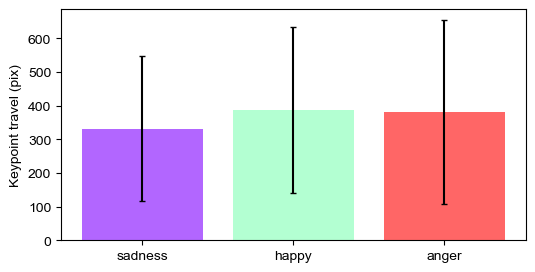

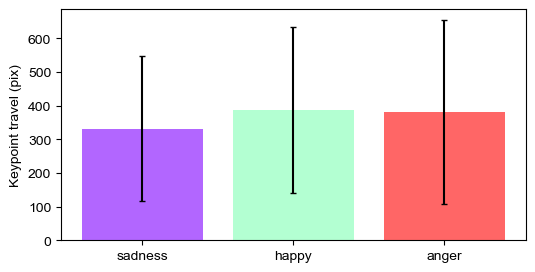

In [19]:
kp_travel = analyze.get_keypoint_travel(config,"kp_48",
                                    0,
                                    3,
                                    binsize=3,
                                    thresh=1e80,
                                    selected_subgroups=["sadness","happy","anger"],
                                    return_as_df=False)

plot.plot_keypoint_travel(kp_travel,cmap="rainbow")

Ellipse only drawn for embeddings_object of class LDA, not <class 'sklearn.decomposition._pca.PCA'>


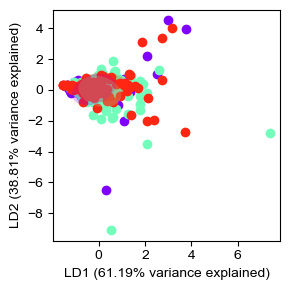

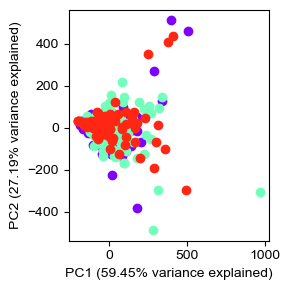

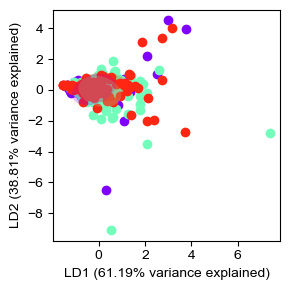

In [20]:
kp_travel = analyze.get_keypoint_travel(config,"kp_48",
                                    0,
                                    3,
                                    binsize=1,
                                    thresh=1e80,
                                    selected_subgroups=["sadness","happy","anger"],
                                    return_as_df=False)

emb_pca = analyze.embed(kp_travel,method="pca")
plot.plot_embeddings(kp_travel,emb_pca,cmap="rainbow")

emb_lda = analyze.embed(kp_travel, method="lda")
plot.plot_embeddings(kp_travel, emb_lda,cmap="rainbow")

0.49107142857142855


([<matplotlib.axis.YTick at 0x7fd6fc1b30d0>,
 [Text(0, 0, 'sadness'), Text(0, 1, 'happy'), Text(0, 2, 'anger')])

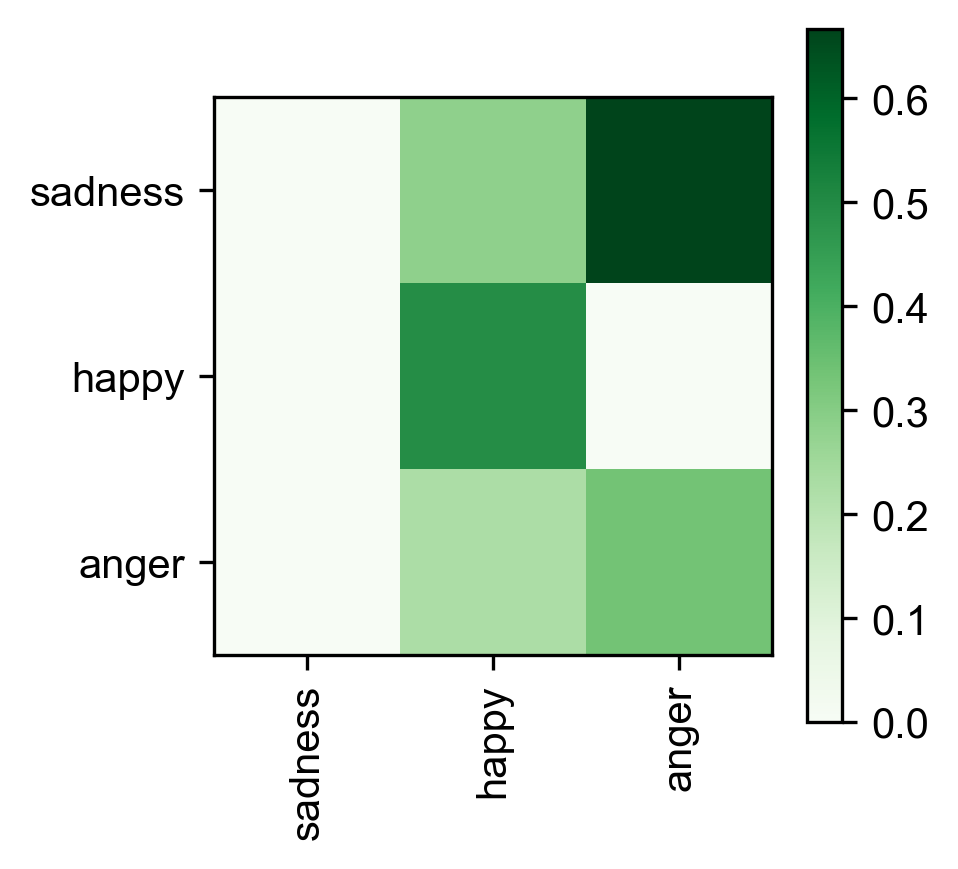

In [21]:
accuracy, conf = analyze.loocv(kp_travel,method="LogisticRegression")
print(accuracy)

conf_sum = np.sum(conf, axis=0)
mask = (conf_sum == 0)
conf_sum[mask] = 1
conf_norm = conf / conf_sum

plt.figure(figsize=(3,3),dpi=300)
plt.imshow(conf_norm,cmap="Greens")
plt.colorbar()
groups = list(kp_travel.group_dict.keys())
plt.xticks(np.arange(0,len(groups),1),labels=groups,rotation=90)
plt.yticks(np.arange(0,len(groups),1),labels=groups)

## 8.2: Measuring and using ego-centered facial kinematics from OpenFace data
Travel of a single keypoint of interest can be useful for measuring overall movement of the head, but additional insight can be gained by ego-centering the data (i.e., using two keypoints to establish the origin and axis along which to reorient all points to) and evaluating the angle, location, and movement of keypoints relative to the new orientation. Ego-centering is acheived in MARIPoSA with analyze.ego_center(), which may be useful to know if you want to save the ego-centered data for some reason. Below is the documentation for analyze.ego_center and a movie plotting the original and ego-centered data.

In [22]:
help(analyze.ego_center)

Help on function ego_center in module utils.analyze:

ego_center(config, data, keypoint_ego1, keypoint_ego2)
    Ego centering a single pose estimation dataframe
    
    :param config: config
    :param data: pose estimation pandas dataframe in DLC format
    :param keypoint_ego1: first keypoint to use for establishing egocentric alignment axis
    :param keypoint_ego2: second keypoint to use for establishing egocentric alignment axis
    :return: ego_centered pandas dataframe


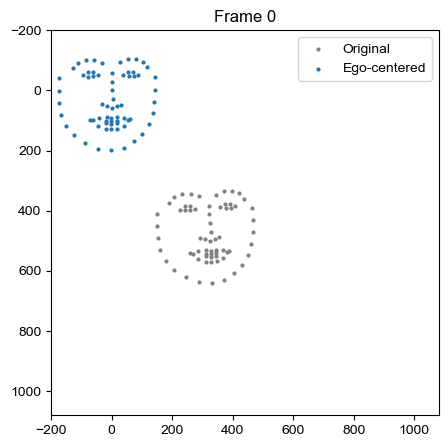

In [23]:
filepath = config["data_directory"]+config["project_files"][1]
data = analyze.read_openface_csv(config, filepath)
data_reoriented = analyze.ego_center(config, data, "kp_27","kp_33")

fig, ax = plt.subplots(figsize=(5, 5))

def update(fr):
    ax.clear()
    x = data.xs("x", level=1, axis=1).loc[fr]
    y = data.xs("y", level=1, axis=1).loc[fr]
    x_ego = data_reoriented.xs("x", level=1, axis=1).loc[fr]
    y_ego = data_reoriented.xs("y", level=1, axis=1).loc[fr]
    
    ax.scatter(x, y, color="gray", s=4, label="Original")
    ax.scatter(x_ego, y_ego, color="C0", s=4, label="Ego-centered")
    ax.set_xlim([-200, 1080])
    ax.set_ylim([-200, 1080])
    ax.set_title(f"Frame {fr}")
    ax.legend(loc="upper right")
    plt.gca().invert_yaxis()

nframes=100
ani = FuncAnimation(fig, update, frames=nframes, interval=50)
HTML(ani.to_jshtml())

In [24]:
print("Getting angle kinematics ...")
angle = analyze.get_keypoint_kinematics(config,"kp_27","kp_33",0,1,
                            metric="angle_m",
                            thresh=70,
                            selected_subgroups=["contempt","surprise","happy","anger","sadness"],
                            return_as_df=False)
print("Getting distance kinematics ...")
distance = analyze.get_keypoint_kinematics(config,"kp_27","kp_33",0,1,
                            metric="distance_m",
                            thresh=70,
                            selected_subgroups=["contempt","surprise","happy","anger","sadness"],
                            return_as_df=False)
print("Getting travel kinematics ...")
travel = analyze.get_keypoint_kinematics(config,"kp_27","kp_33",0,1,
                            metric="travel",
                            thresh=70,
                            selected_subgroups=["contempt","surprise","happy","anger","sadness"],
                            return_as_df=False)

Getting angle kinematics ...
Getting distance kinematics ...
Getting travel kinematics ...


Accuracy: 0.4532967032967033


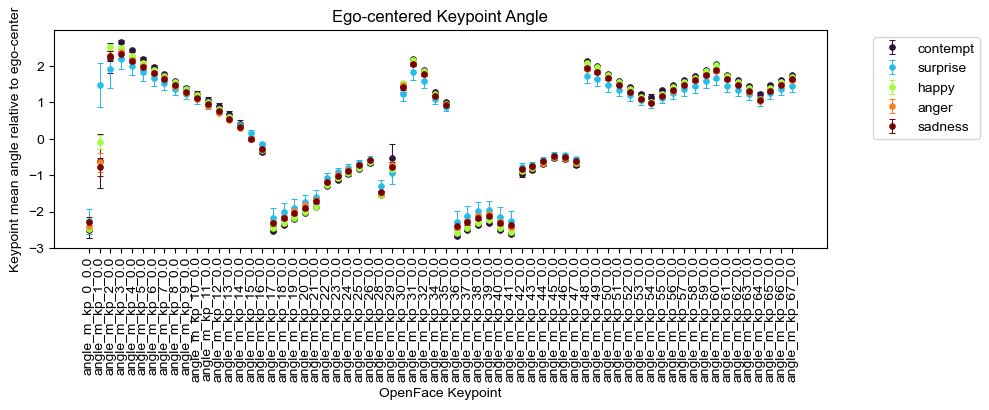

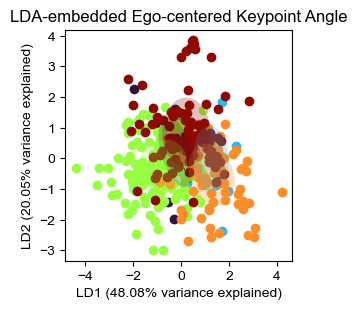

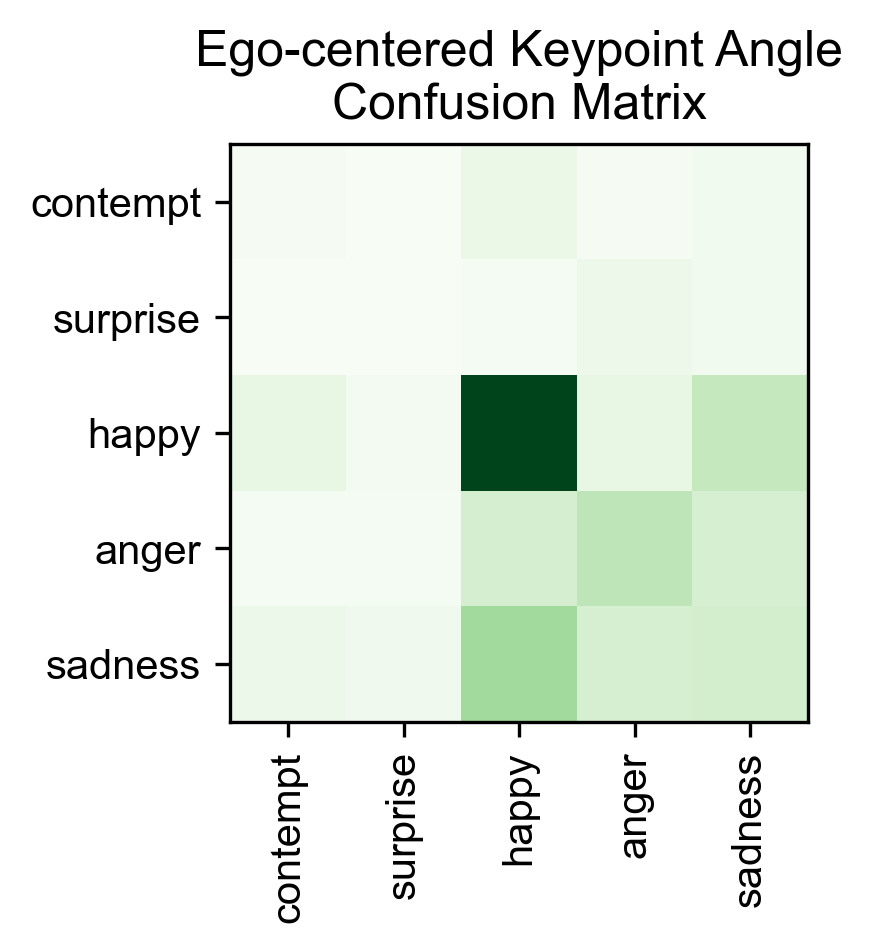

In [25]:
plot.plot_keypoint_kinematics(config,angle,figW=10,figH=4,style="points",cmap="turbo")
plt.title("Ego-centered Keypoint Angle")

emb = analyze.embed(angle)
plot.plot_embeddings(angle,emb,cmap="turbo")
plt.title("LDA-embedded Ego-centered Keypoint Angle")

plt.figure(figsize=(2.5,2.5),dpi=300)
plt.title("Ego-centered Keypoint Angle\nConfusion Matrix")
acc, cm = analyze.loocv(angle)
plt.imshow(cm,cmap="Greens")
ticklabels=["contempt","surprise","happy","anger","sadness"]
plt.xticks(range(len(ticklabels)),labels=ticklabels,rotation=90)
plt.yticks(range(len(ticklabels)),labels=ticklabels)
print(f"Accuracy: {acc}")

Accuracy: 0.5054945054945055


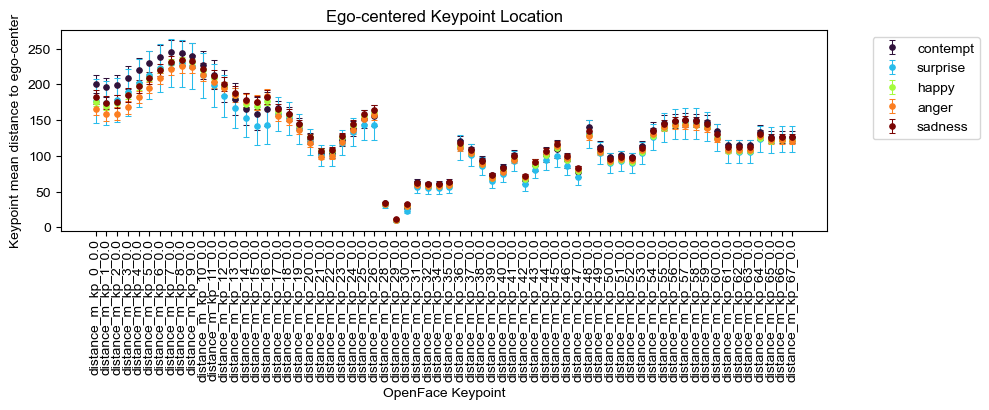

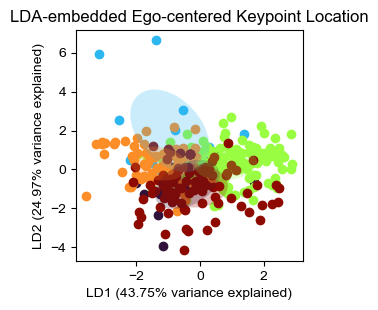

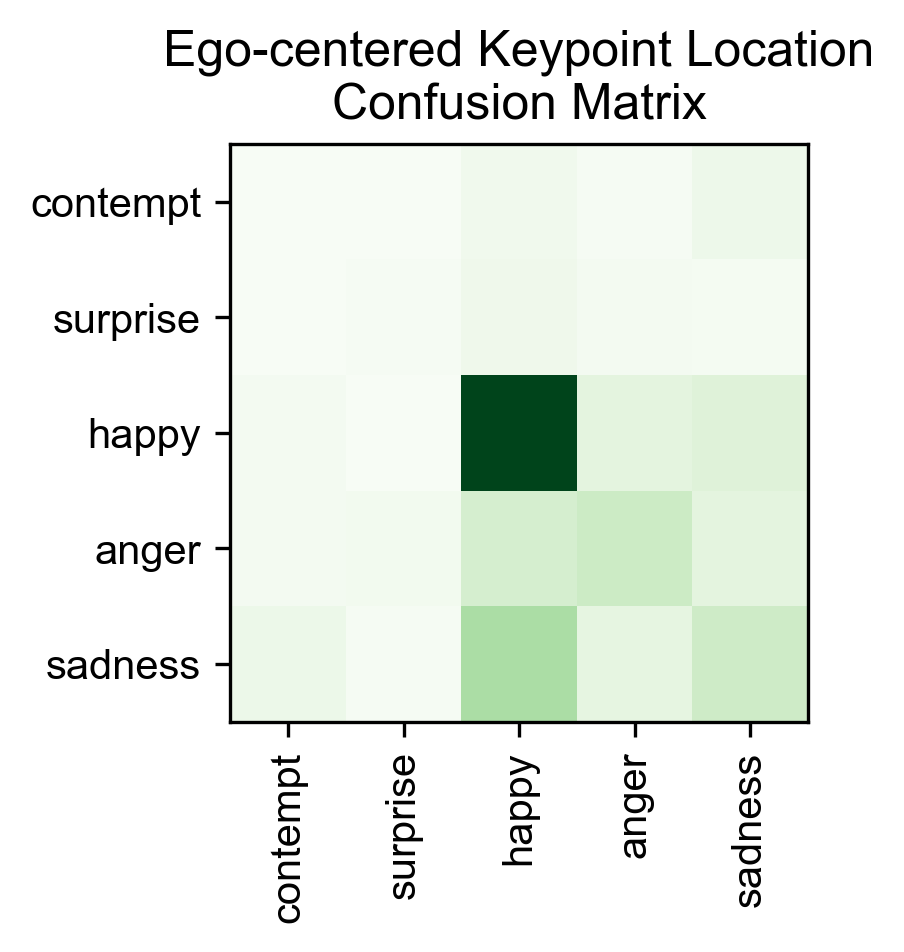

In [26]:
plot.plot_keypoint_kinematics(config,distance,figW=10,figH=4,style="points",cmap="turbo")
plt.title("Ego-centered Keypoint Location")

emb = analyze.embed(distance)
plot.plot_embeddings(distance,emb,cmap="turbo")
plt.title("LDA-embedded Ego-centered Keypoint Location")

plt.figure(figsize=(2.5,2.5),dpi=300)
plt.title("Ego-centered Keypoint Location\nConfusion Matrix")
acc, cm = analyze.loocv(distance)
plt.imshow(cm,cmap="Greens")
ticklabels=["contempt","surprise","happy","anger","sadness"]
plt.xticks(range(len(ticklabels)),labels=ticklabels,rotation=90)
plt.yticks(range(len(ticklabels)),labels=ticklabels)
print(f"Accuracy: {acc}")

Accuracy: 0.45054945054945056


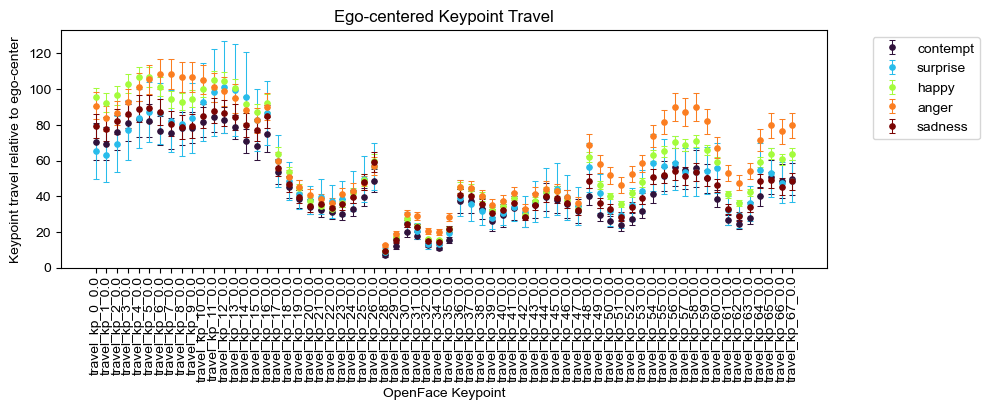

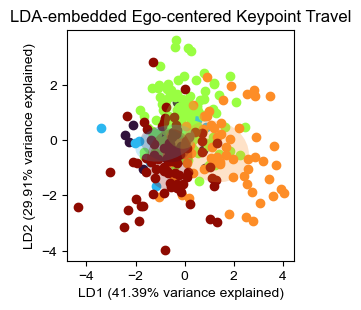

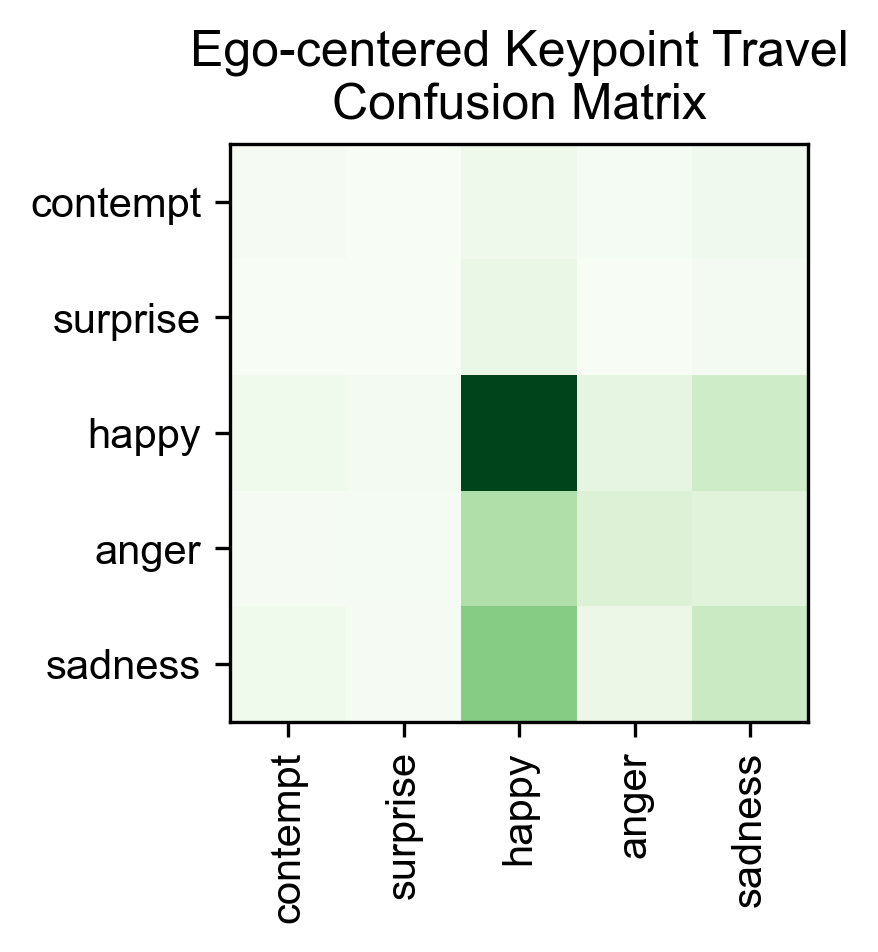

In [27]:
plot.plot_keypoint_kinematics(config,travel,figW=10,figH=4,style="points",cmap="turbo")
plt.title("Ego-centered Keypoint Travel")

emb = analyze.embed(travel)
plot.plot_embeddings(travel,emb,cmap="turbo")
plt.title("LDA-embedded Ego-centered Keypoint Travel")

plt.figure(figsize=(2.5,2.5),dpi=300)
plt.title("Ego-centered Keypoint Travel\nConfusion Matrix")
acc, cm = analyze.loocv(travel)
plt.imshow(cm,cmap="Greens")
ticklabels=["contempt","surprise","happy","anger","sadness"]
plt.xticks(range(len(ticklabels)),labels=ticklabels,rotation=90)
plt.yticks(range(len(ticklabels)),labels=ticklabels)
print(f"Accuracy: {acc}")

## 8.3 Working with Action Units
Next, we can look at action units, which are indexed metrics describing use of particular muscles on the face. This form of data has its own class called ActionUnits which can also be embedded, classified, and visualized like other forms of data extracted from video analyses in MARIPoSA.

In [28]:
start = 0
end = 3
binsize = 3

selected_subgroups=None

au = analyze.get_action_units(config,start,end,binsize=binsize,selected_subgroups=["sadness","happy","anger"],)
au = au.scale()

Ellipse only drawn for embeddings_object of class LDA, not <class 'sklearn.decomposition._pca.PCA'>


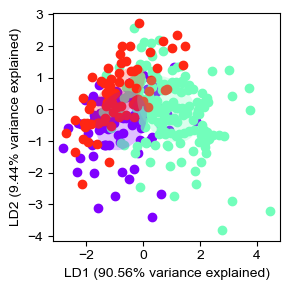

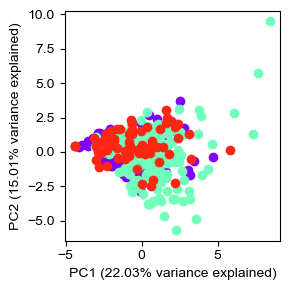

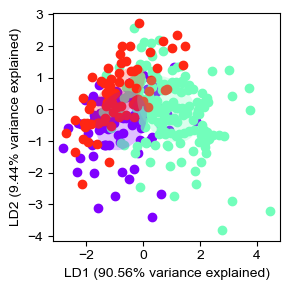

In [29]:
emb_pca = analyze.embed(au,method="pca")
plot.plot_embeddings(au,emb_pca,cmap="rainbow")
emb_lda = analyze.embed(au,method="lda")
plot.plot_embeddings(au,emb_lda,cmap="rainbow")

0.5892857142857143


([<matplotlib.axis.YTick at 0x7fd6d03bfe20>,
 [Text(0, 0, 'sadness'), Text(0, 1, 'happy'), Text(0, 2, 'anger')])

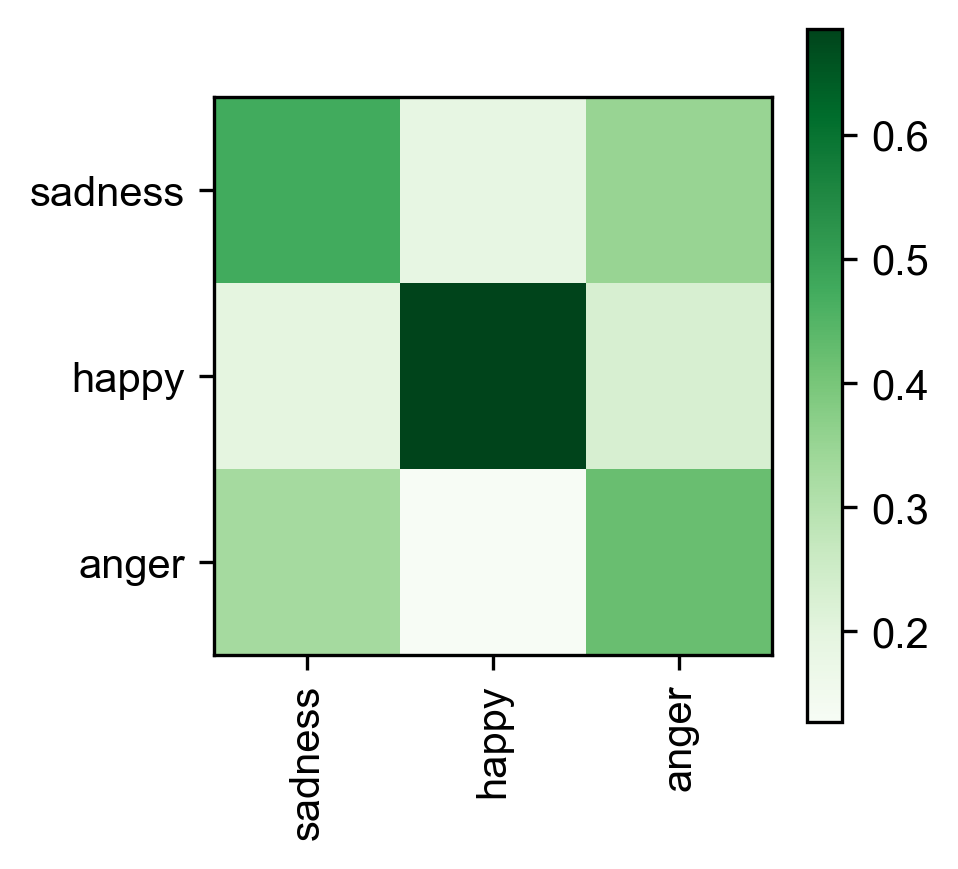

In [30]:
accuracy, conf = analyze.loocv(au,method="randomforest")
print(accuracy)
conf_sum = np.sum(conf, axis=0)
mask = (conf_sum == 0)
conf_sum[mask] = 1
conf_norm = conf / conf_sum

plt.figure(figsize=(3,3),dpi=300)
plt.imshow(conf_norm,cmap="Greens")
plt.colorbar()
groups = list(kp_travel.group_dict.keys())
plt.xticks(np.arange(0,len(groups),1),labels=groups,rotation=90)
plt.yticks(np.arange(0,len(groups),1),labels=groups)